Used for descriptive statistics of distributions of latin square counterbalancing

In [5]:
from __future__ import annotations

import csv
from pathlib import Path
import matplotlib.pyplot as plt


TEXTS = ("Bees", "Hubble", "Salt")
CONDITIONS = ("none", "full", "eyetracked")


def _to_float(value: str) -> float | None:
	text = (value or "").strip()
	if not text:
		return None
	try:
		return float(text)
	except ValueError:
		return None


def _mean(values: list[float]) -> float | None:
	if not values:
		return None
	return sum(values) / len(values)


def _fmt(value: float | None) -> str:
	if value is None:
		return "N/A"
	return f"{value:.3f}"

Section for questionnaire per reading condition, eye strain

In [6]:
import pandas as pd
from IPython.display import display

csv_path = Path("aggregated_questionnaire_metrics.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find questionnaire CSV: {csv_path}")

with csv_path.open("r", encoding="utf-8-sig", newline="") as handle:
    reader = csv.DictReader(handle)
    rows = list(reader)

eye_all: list[float] = []
nasa_all: list[float] = []
eye_by_text: dict[str, list[float]] = {text: [] for text in TEXTS}
eye_by_condition: dict[str, list[float]] = {condition: [] for condition in CONDITIONS}
nasa_by_text: dict[str, list[float]] = {text: [] for text in TEXTS}

for row in rows:
    condition_by_text: dict[str, str] = {}
    for text in TEXTS:
        condition_col = f'Text filtering condition "{text}"'
        condition_value = (row.get(condition_col, "") or "").strip().lower()
        if condition_value in CONDITIONS:
            condition_by_text[text] = condition_value

    for key, raw in row.items():
        if key is None:
            continue

        val = _to_float(raw)
        if val is None:
            continue

        if key.startswith('Text questionnaire ') and '"' in key:
            eye_all.append(val)
            for text in TEXTS:
                if f'"{text}"' in key:
                    eye_by_text[text].append(val)
                    condition = condition_by_text.get(text)
                    if condition:
                        eye_by_condition[condition].append(val)
                    break

        if key.startswith('NASA TLX overall ') and '"' in key:
            nasa_all.append(val)
            for text in TEXTS:
                if f'"{text}"' in key:
                    nasa_by_text[text].append(val)
                    break

overall_table = pd.DataFrame([
    {
        "Metric": "Eye score",
        "Average": _mean(eye_all),
    },
    {
        "Metric": "NASA TLX score",
        "Average": _mean(nasa_all),
    },
])

eye_by_text_table = pd.DataFrame(
    [{"Text": text, "Average eye score": _mean(eye_by_text[text])} for text in TEXTS]
 )

eye_by_condition_table = pd.DataFrame(
    [{"Condition": condition, "Average eye score": _mean(eye_by_condition[condition])} for condition in CONDITIONS]
 )

nasa_by_text_table = pd.DataFrame(
    [{"Text": text, "Average NASA TLX score": _mean(nasa_by_text[text])} for text in TEXTS]
 )

overall_table["Average"] = overall_table["Average"].round(3)
eye_by_text_table["Average eye score"] = eye_by_text_table["Average eye score"].round(3)
eye_by_condition_table["Average eye score"] = eye_by_condition_table["Average eye score"].round(3)
nasa_by_text_table["Average NASA TLX score"] = nasa_by_text_table["Average NASA TLX score"].round(3)

display(overall_table)
display(eye_by_text_table)
display(eye_by_condition_table)
display(nasa_by_text_table)

,Metric,Average
0,Eye score,17.468
1,NASA TLX score,6.264


,Text,Average eye score
0,Bees,17.231
1,Hubble,16.361
2,Salt,18.810


,Condition,Average eye score
0,none,21.023
1,full,14.574
2,eyetracked,16.806


,Text,Average NASA TLX score
0,Bees,6.708
1,Hubble,6.208
2,Salt,5.875


Check averages of eye events per reading section

In [7]:
import pandas as pd
from IPython.display import display

reading_csv_path = Path("aggregated_reading_eye_metrics.csv")
if not reading_csv_path.exists():
    raise FileNotFoundError(f"Could not find reading CSV: {reading_csv_path}")

with reading_csv_path.open("r", encoding="utf-8-sig", newline="") as handle:
    reader = csv.DictReader(handle)
    reading_rows = list(reader)

event_columns = [
    "Saccade count",
    "Saccade avg duration",
    "Fixation count",
    "Fixation avg duration",
    "Blink count",
    "Blink avg duration",
]

by_section: dict[str, dict[str, list[float]]] = {}
by_condition: dict[str, dict[str, list[float]]] = {
    condition: {column: [] for column in event_columns}
    for condition in CONDITIONS
}

for row in reading_rows:
    section = (row.get("Reading paragraph", "") or "").strip()
    condition = (row.get("Condition", "") or "").strip().lower()

    if section:
        section_bucket = by_section.setdefault(
            section,
            {column: [] for column in event_columns},
        )
        for column in event_columns:
            value = _to_float(row.get(column, ""))
            if value is not None:
                section_bucket[column].append(value)

    if condition in by_condition:
        condition_bucket = by_condition[condition]
        for column in event_columns:
            value = _to_float(row.get(column, ""))
            if value is not None:
                condition_bucket[column].append(value)

section_rows: list[dict[str, object]] = []
for section in sorted(by_section):
    row_out: dict[str, object] = {"Reading section": section}
    for column in event_columns:
        row_out[column] = _mean(by_section[section][column])
    section_rows.append(row_out)

condition_rows: list[dict[str, object]] = []
for condition in CONDITIONS:
    row_out = {"Condition": condition}
    for column in event_columns:
        row_out[column] = _mean(by_condition[condition][column])
    condition_rows.append(row_out)

section_table = pd.DataFrame(section_rows)
condition_table = pd.DataFrame(condition_rows)

numeric_cols_section = [c for c in section_table.columns if c != "Reading section"]
numeric_cols_condition = [c for c in condition_table.columns if c != "Condition"]
section_table[numeric_cols_section] = section_table[numeric_cols_section].round(3)
condition_table[numeric_cols_condition] = condition_table[numeric_cols_condition].round(3)

display(section_table)
display(condition_table)

,Reading section,Saccade count,Saccade avg duration,Fixation count,Fixation avg duration,Blink count,Blink avg duration
0,Bees,508.042,37.306,222.333,91.341,12.625,183.717
1,Hubble,569.375,38.370,225.750,96.655,14.458,205.527
2,Salt,503.167,38.166,250.375,98.381,13.667,223.848


,Condition,Saccade count,Saccade avg duration,Fixation count,Fixation avg duration,Blink count,Blink avg duration
0,none,444.292,37.964,227.792,91.087,13.333,185.425
1,full,459.542,38.131,234.083,98.853,13.833,215.793
2,eyetracked,676.750,37.747,236.583,96.437,13.583,211.874


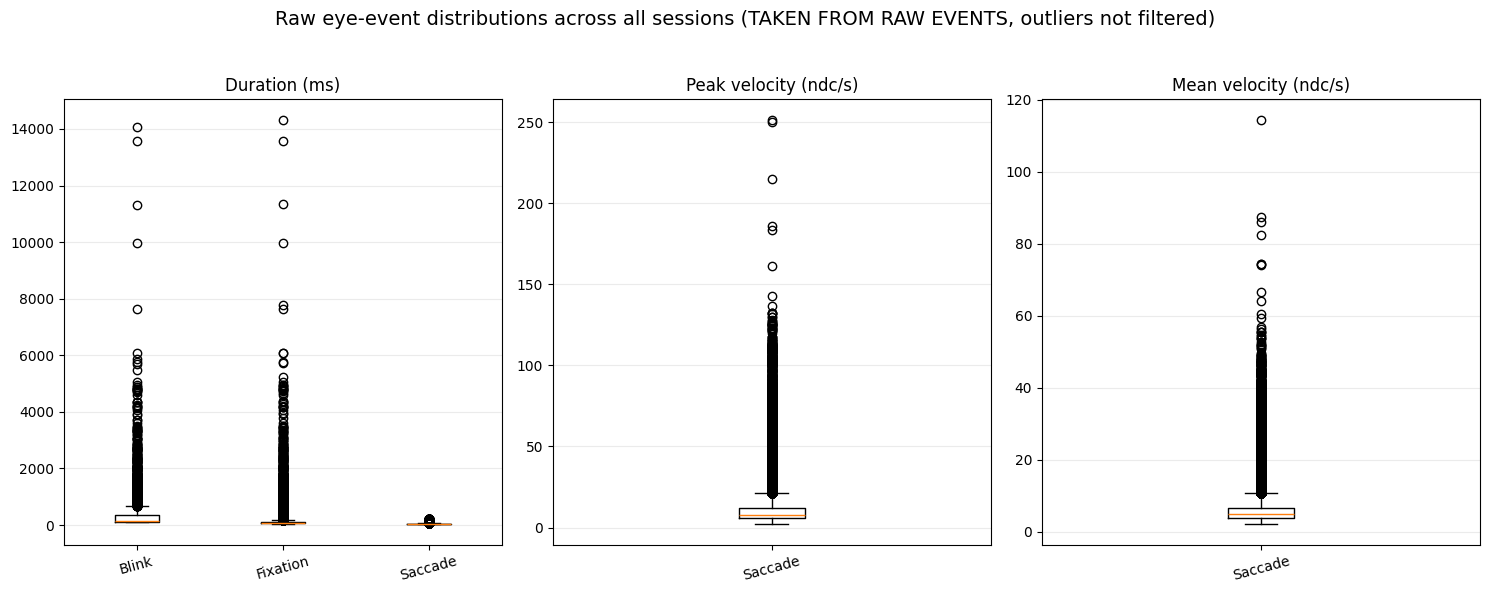

Loaded 24 eye_events.csv files with 190,089 total rows
            duration_ms  peak_velocity_ndc_per_s  mean_velocity_ndc_per_s
event_type                                                               
blink              6611                        0                        0
fixation          63510                        0                        0
saccade          119968                   119968                   119968


 Blink percentiles
95th:  1176.021
99th:  2711.6462999999985
99.9th:  5805.743510000026

 Fixation percentiles
95th:  236.002
99th:  792.01073
99.9th:  2759.9090180001454

 Saccade percentiles
95th:  79.999
99th:  144.001
99.9th:  188.006033

 Peak velocity percentiles (saccades only)
95th:  33.83323819999998
99th:  62.530932440000036
99.9th:  104.30307988200013

 Mean velocity percentiles (saccades only)
95th:  13.33925035
99th:  22.527805990000004
99.9th:  41.53275711600154


In [8]:
logs_root = Path("..") / "logs"
eye_event_paths = sorted(logs_root.glob("P*/S*/eye_events.csv"))
if not eye_event_paths:
    raise FileNotFoundError(f"No eye_events.csv files found under {logs_root}")

frames: list[pd.DataFrame] = []
for path in eye_event_paths:
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        rows = list(reader)
    if not rows:
        continue
    frame = pd.DataFrame(rows)
    frame["source_file"] = str(path)
    frames.append(frame)

if not frames:
    raise ValueError("No rows found in any eye_events.csv file")

eye_events = pd.concat(frames, ignore_index=True)
eye_events["event_type"] = eye_events["event_type"].astype(str).str.strip().str.lower()

for column in ["duration_ms", "peak_velocity_ndc_per_s", "mean_velocity_ndc_per_s"]:
    eye_events[column] = pd.to_numeric(eye_events[column], errors="coerce")

plot_specs = [
    ("duration_ms", "Duration (ms)", ["blink", "fixation", "saccade"]),
    ("peak_velocity_ndc_per_s", "Peak velocity (ndc/s)", ["saccade"]),
    ("mean_velocity_ndc_per_s", "Mean velocity (ndc/s)", ["saccade"]),
]

fig, axes = plt.subplots(nrows=1, ncols=len(plot_specs), figsize=(5 * len(plot_specs), 6))
if len(plot_specs) == 1:
    axes = [axes]

for ax, (column, title, event_order) in zip(axes, plot_specs):
    plot_data = []
    labels = []
    for event_type in event_order:
        values = eye_events.loc[eye_events["event_type"] == event_type, column].dropna().tolist()
        if values:
            plot_data.append(values)
            labels.append(event_type.title())
    if not plot_data:
        ax.set_title(f"No data for {title}")
        ax.axis("off")
        continue
    ax.boxplot(plot_data, tick_labels=labels, showfliers=True, vert=True)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Raw eye-event distributions across all sessions (TAKEN FROM RAW EVENTS, outliers not filtered)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"Loaded {len(eye_event_paths)} eye_events.csv files with {len(eye_events):,} total rows")
print(eye_events[["event_type", "duration_ms", "peak_velocity_ndc_per_s", "mean_velocity_ndc_per_s"]].groupby("event_type").count())

#Blink percentiles
print("\n\n Blink percentiles")
print("95th: ", eye_events.loc[eye_events["event_type"] == "blink", "duration_ms"].quantile(0.95))
print("99th: ", eye_events.loc[eye_events["event_type"] == "blink", "duration_ms"].quantile(0.99))
print("99.9th: ", eye_events.loc[eye_events["event_type"] == "blink", "duration_ms"].quantile(0.999))

#Fixation percentiles
print("\n Fixation percentiles")
print("95th: ", eye_events.loc[eye_events["event_type"] == "fixation", "duration_ms"].quantile(0.95))
print("99th: ", eye_events.loc[eye_events["event_type"] == "fixation", "duration_ms"].quantile(0.99))
print("99.9th: ", eye_events.loc[eye_events["event_type"] == "fixation", "duration_ms"].quantile(0.999))

#Saccade percentiles
print("\n Saccade percentiles")
print("95th: ", eye_events.loc[eye_events["event_type"] == "saccade", "duration_ms"].quantile(0.95))
print("99th: ", eye_events.loc[eye_events["event_type"] == "saccade", "duration_ms"].quantile(0.99))
print("99.9th: ", eye_events.loc[eye_events["event_type"] == "saccade", "duration_ms"].quantile(0.999))

print("\n Peak velocity percentiles (saccades only)")
print("95th: ", eye_events.loc[eye_events["event_type"] == "saccade", "peak_velocity_ndc_per_s"].quantile(0.95))
print("99th: ", eye_events.loc[eye_events["event_type"] == "saccade", "peak_velocity_ndc_per_s"].quantile(0.99))
print("99.9th: ", eye_events.loc[eye_events["event_type"] == "saccade", "peak_velocity_ndc_per_s"].quantile(0.999))

print("\n Mean velocity percentiles (saccades only)")
print("95th: ", eye_events.loc[eye_events["event_type"] == "saccade", "mean_velocity_ndc_per_s"].quantile(0.95))
print("99th: ", eye_events.loc[eye_events["event_type"] == "saccade", "mean_velocity_ndc_per_s"].quantile(0.99))
print("99.9th: ", eye_events.loc[eye_events["event_type"] == "saccade", "mean_velocity_ndc_per_s"].quantile(0.999))
